# Download gridded observational data. 

Here I will use NRCan (Natural Resources Canada) gridded observations, derived from station observations using the ANUSPLIN interpolation algorithm. The spatial resolution is 10 km*10 km, and data is available from 1950-2017. More information on this dataset can be found in McKenney et al. [2011].

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from siphon.catalog import TDSCatalog
import os
import json
import requests
from tqdm import tqdm

# import necessary packages
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())
import ec3
import requests
# import nc_time_axis
from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indices as xci
from xclim import sdba

# for getting data from the ESGF
from pyesgf.search import SearchConnection
import os
from os import listdir
from os.path import isfile, exists, getsize
os.environ["ESGF_PYCLIENT_NO_FACETS_STAR_WARNING"] = "on"

/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/indices/fire/_cffwis.py:207: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _day_length(lat: int | float, mth: int):  # pragma: no cover
/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/indices/fire/_cffwis.py:227: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for de

In [47]:
# this is the URL for PAVICS' THREDDS server which hosts gridded observations. You can
# enter this URL into a browser (but change the .xml to .html) to explore the data catalog
url_gridded_obs = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/gridded_obs/catalog.xml"

# Create Catalog object - this contains the info for the datasets in this directory
cat = TDSCatalog(url_gridded_obs)

for dataset in cat.datasets:
    print(dataset)

nrcan.ncml
nrcan_v2.ncml


In [3]:
# there are two versions of the NRCAN dataset. We will use the more recent one, version 2.
cds = cat.datasets[1] 

# open the dataset using the OPenDAP URL. Passing chunks = 'auto' will speed up processing
# using dask under the hood, and will also allow you to process a larger volume of data 
# over OPenDAP.
nrcan_ds = xr.open_dataset(cds.access_urls["OPENDAP"], chunks = 'auto')

# this will print out an interactive summary of the contents of the dataset
nrcan_ds

<xarray.Dataset>
Dimensions:  (lat: 510, lon: 1068, time: 24837)
Coordinates:
  * lat      (lat) float32 83.46 83.38 83.29 83.21 ... 41.29 41.21 41.12 41.04
  * lon      (lon) float32 -141.0 -140.9 -140.8 -140.7 ... -52.21 -52.13 -52.04
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 2017-12-31
Data variables:
    tasmin   (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
    tasmax   (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
    pr       (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
Attributes: (12/15)
    Conventions:          CF-1.5
    title:                NRCAN ANUSPLIN daily gridded dataset : version 2
    history:              Fri Jan 25 14:11:15 2019 : Convert from original fo...
    institute_id:         NRCAN
    frequency:            day
    abstract:             Gridded daily observational dataset produced by Nat...
    ...                   ...
    dataset_id:           NRCAN_anusplin_daily_v2
    version:              2.0
    license_type:         permissive
    license:              https://open.canada.ca/en/open-government-licence-c...
    attribution:          The authors provide this data under the Environment...
    citation:             Natural Resources Canada ANUSPLIN interpolated hist...

In [4]:
# subset for Canadian Arctic
lat_bnds = [90, 65]
lon_bnds = [-142, -60]

ds_region = nrcan_ds.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

# Convert the unit of tasmax from K to degree Celsius
# ds_region['tasmax'] = ds_region['tasmax'] - 273.15
# update the units in the file as well
# ds_region['tasmax'].attrs['units'] = 'degC'

ds_region

<xarray.Dataset>
Dimensions:  (lat: 222, lon: 972, time: 24837)
Coordinates:
  * lat      (lat) float32 83.46 83.38 83.29 83.21 ... 65.29 65.21 65.12 65.04
  * lon      (lon) float32 -141.0 -140.9 -140.8 -140.7 ... -60.21 -60.13 -60.04
  * time     (time) datetime64[ns] 1950-01-01 1950-01-02 ... 2017-12-31
Data variables:
    tasmin   (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
    tasmax   (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
    pr       (time, lat, lon) float32 dask.array<chunksize=(3375, 69, 144), meta=np.ndarray>
Attributes: (12/15)
    Conventions:          CF-1.5
    title:                NRCAN ANUSPLIN daily gridded dataset : version 2
    history:              Fri Jan 25 14:11:15 2019 : Convert from original fo...
    institute_id:         NRCAN
    frequency:            day
    abstract:             Gridded daily observational dataset produced by Nat...
    ...                   ...
    dataset_id:           NRCAN_anusplin_daily_v2
    version:              2.0
    license_type:         permissive
    license:              https://open.canada.ca/en/open-government-licence-c...
    attribution:          The authors provide this data under the Environment...
    citation:             Natural Resources Canada ANUSPLIN interpolated hist...

We can take a peek at the data for a particular day and plot it on a map using the package cartopy.

KeyboardInterrupt: 

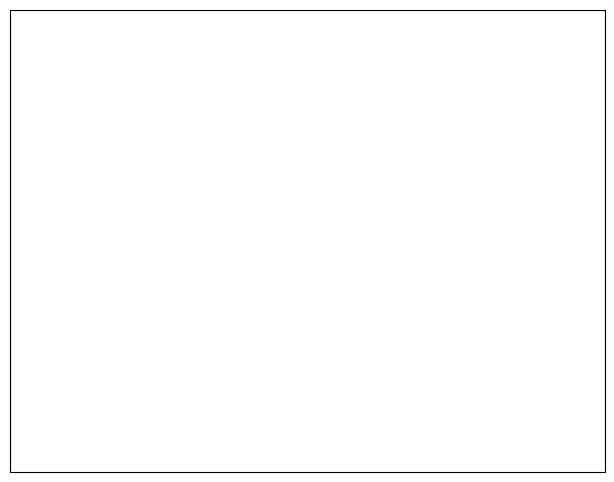

In [10]:
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# select the temperature data for a particular day
sample_time = '2017-08-01'
temp_sample = ds_region.tasmax.sel(time = sample_time) 
temp_sample = temp_sample - 273.15 # Convert from K to degree Celsius

# plot the data with 20 filled contours
temp_sample.plot.contourf(ax = ax, 
                          transform = ccrs.PlateCarree(),
                          levels = 20, 
                          cbar_kwargs = {'label': r'Temperature ($^{\circ}$C)', 'orientation': 'vertical'}
                         )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title(f"Temperature on {sample_time}")

plt.show()

## Gridded temperature from Berkeley Earth

Since the NRCan data only has maximum and minimum daily temperature, I will also obtain gridded temperature data from Berkeley Earth, which has mean daily temperature. The dataset was downloaded from https://berkeleyearth.org/data/

In [5]:
# Let's look at the dataset
xr.open_mfdataset("data-raw/climate-data/TAVG_Daily_2000.nc")

<xarray.Dataset>
Dimensions:      (longitude: 360, latitude: 180, time: 3653, day_number: 365)
Coordinates:
  * longitude    (longitude) float32 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude     (latitude) float32 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
Dimensions without coordinates: time, day_number
Data variables:
    date_number  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    year         (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    month        (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    day          (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    day_of_year  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    land_mask    (latitude, longitude) float64 dask.array<chunksize=(180, 360), meta=np.ndarray>
    temperature  (time, latitude, longitude) float32 dask.array<chunksize=(3653, 180, 360), meta=np.ndarray>
    climatology  (day_number, latitude, longitude) float32 dask.array<chunksize=(365, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:     Berkeley Earth Internal Convention (based on CF-1.5)
    title:           Gridded Berkeley Earth Surface Temperature Anomaly Field
    history:         07-Sep-2022 00:25:53
    institution:     Berkeley Earth Surface Temperature Project
    source_history:  06-Sep-2022 15:50:29
    comment:         This file contains surface temperature anomaly field gri...

Each decade is stored as a separate netCDF file. Year, month, and day are stored as separate variables rather than a single time coordinate. This would cause problem when we read multiple netCDF files at the same time. Therefore, We will define a preprocessing function to combine year, month, and day into a proper time coordinate in xarray, then preprocess to fix each file before concatenation.

In [6]:
# Define a preprocessing function to combine year, month, and day variables into a time coordinate
def add_time_coord(ds):
    # Combine year, month, and day into a datetime array
    time = pd.to_datetime({
    "year": ds["year"].values,
    "month": ds["month"].values,
    "day": ds["day"].values
    })

    # Assign time coordinate
    ds = ds.assign_coords(time=("time", time))
    
    # Drop the year, month, and day variables
    ds = ds.drop_vars(["year", "month", "day"])

    return ds

# Open all the datasets
historical = xr.open_mfdataset("data-raw/climate-data/TAVG_Daily_*.nc", 
                 preprocess = add_time_coord,
                 combine = "by_coords")

In [7]:
historical

<xarray.Dataset>
Dimensions:      (longitude: 360, latitude: 180, time: 7305, day_number: 365)
Coordinates:
  * longitude    (longitude) float32 -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude     (latitude) float32 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time         (time) datetime64[ns] 2000-01-01 2000-01-02 ... 2019-12-31
Dimensions without coordinates: day_number
Data variables:
    date_number  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    day_of_year  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    land_mask    (time, latitude, longitude) float64 dask.array<chunksize=(3653, 180, 360), meta=np.ndarray>
    temperature  (time, latitude, longitude) float32 dask.array<chunksize=(3653, 180, 360), meta=np.ndarray>
    climatology  (time, day_number, latitude, longitude) float32 dask.array<chunksize=(3653, 365, 180, 360), meta=np.ndarray>
Attributes:
    Conventions:     Berkeley Earth Internal Convention (based on CF-1.5)
    title:           Gridded Berkeley Earth Surface Temperature Anomaly Field
    history:         07-Sep-2022 00:25:53
    institution:     Berkeley Earth Surface Temperature Project
    source_history:  06-Sep-2022 15:50:29
    comment:         This file contains surface temperature anomaly field gri...

In [8]:
# subset for Canadian Arctic
lat_bnds = [65, 90]
lon_bnds = [-142, -60]

ds_region = historical.sel(latitude = slice(*lat_bnds), longitude = slice(*lon_bnds))
ds_region

<xarray.Dataset>
Dimensions:      (longitude: 82, latitude: 25, time: 7305, day_number: 365)
Coordinates:
  * longitude    (longitude) float32 -141.5 -140.5 -139.5 ... -62.5 -61.5 -60.5
  * latitude     (latitude) float32 65.5 66.5 67.5 68.5 ... 86.5 87.5 88.5 89.5
  * time         (time) datetime64[ns] 2000-01-01 2000-01-02 ... 2019-12-31
Dimensions without coordinates: day_number
Data variables:
    date_number  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    day_of_year  (time) float64 dask.array<chunksize=(3653,), meta=np.ndarray>
    land_mask    (time, latitude, longitude) float64 dask.array<chunksize=(3653, 25, 82), meta=np.ndarray>
    temperature  (time, latitude, longitude) float32 dask.array<chunksize=(3653, 25, 82), meta=np.ndarray>
    climatology  (time, day_number, latitude, longitude) float32 dask.array<chunksize=(3653, 365, 25, 82), meta=np.ndarray>
Attributes:
    Conventions:     Berkeley Earth Internal Convention (based on CF-1.5)
    title:           Gridded Berkeley Earth Surface Temperature Anomaly Field
    history:         07-Sep-2022 00:25:53
    institution:     Berkeley Earth Surface Temperature Project
    source_history:  06-Sep-2022 15:50:29
    comment:         This file contains surface temperature anomaly field gri...

Let's look at the the spatial extent

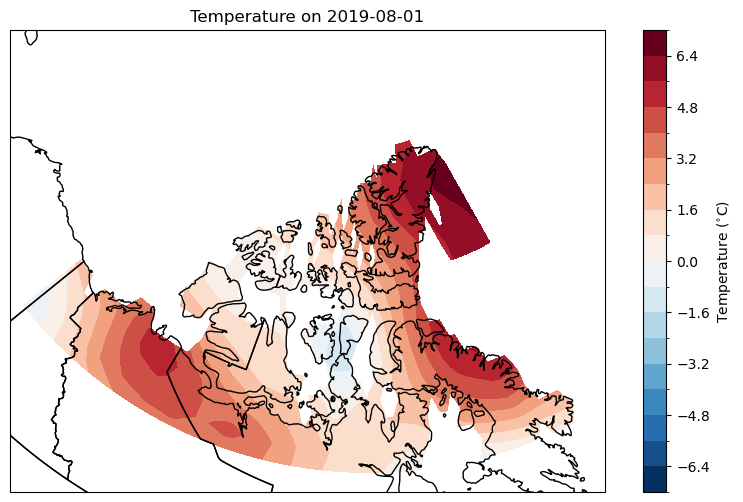

In [9]:
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# select the temperature data for a particular day
sample_time = '2019-08-01'
temp_sample = ds_region.temperature.sel(time = sample_time) 


# plot the data with 20 filled contours
temp_sample.plot.contourf(ax = ax, 
                          transform = ccrs.PlateCarree(),
                          levels = 20, 
                          cbar_kwargs = {'label': r'Temperature ($^{\circ}$C)', 'orientation': 'vertical'}
                         )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title(f"Temperature on {sample_time}")

plt.show()

## Suitability for disease transmission
Then we calculate the thermal suitability

In [2]:
# Load the csv file containing suitability at each temperature
suitability = pd.read_csv("data-processed/S.output.lowerCI.csv") 
suitability = suitability[["temp", "scaled_lowerCI"]]
suitability

,temp,scaled_lowerCI
0,0.0,0.0
1,0.1,0.0
2,0.2,0.0
3,0.3,0.0
4,0.4,0.0
...,...,...
446,44.6,0.0
447,44.7,0.0
448,44.8,0.0
449,44.9,0.0


In [3]:
# Create an interpolation function such that the suitability of any temperature can be calculated (even if it is not in the csv file)

from scipy.interpolate import interp1d
suit_func = interp1d(suitability["temp"], suitability["scaled_lowerCI"], 
                     bounds_error=False, fill_value=0)
suit_func

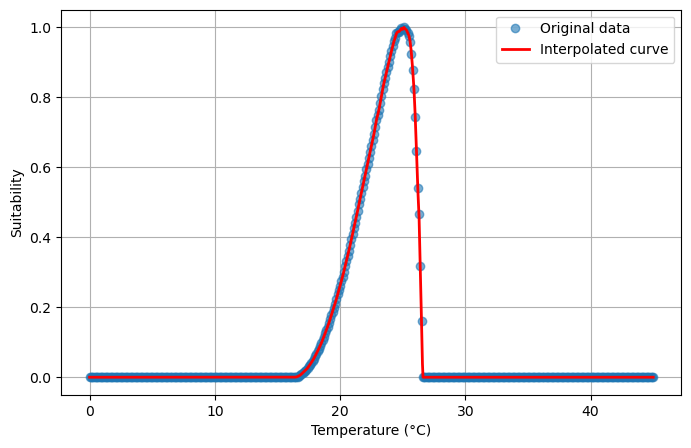

In [4]:
# Check the interpolation function
temps = np.linspace(suitability["temp"].min(), suitability["temp"].max(), 1000)

plt.figure(figsize = (8,5))
plt.plot(suitability["temp"], suitability["scaled_lowerCI"], 'o', label="Original data", alpha=0.6)
plt.plot(temps, suit_func(temps), '-', label = "Interpolated curve", color='red', linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Suitability")
plt.legend()
plt.grid(True)
plt.show()

Below are some functions to calculate thermal suitability and to test whether mean changes are significant. The first function, effective_sample_size, calculates the effective sample size to account for non-independence between serially correlated data points. The second function, get_suitability, calculates the number of days that S(T) > 0.001 for each grid cell in each year, as well as some summary statistics for significance testing.

In [5]:
# function for calculating effective sample size, copied section 3.4 from the guidebook
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

In [6]:
def get_suitability(data, thres = 0.001):
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        # data.temperature,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])
    
    # Get effective sample size for each period, for significance testing later on
    neff = effective_sample_size(S)

    # Count the number of days where S > thres in each year

    # S = S.where(~np.isnan(data.temperature))
    S = S.where(~np.isnan(data.tas))
    
    suit_days = S > thres
    days_per_year = suit_days.groupby("time.year").sum(dim = "time")

    # Keep land mask
    # mask = data.temperature.isel(time=0).isnull()
    mask = data.tas.isel(time=0).isnull()
    days_per_year = days_per_year.where(~mask)
    
    # Summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    suit_days_mean = days_per_year.mean('year') # Calculate the mean # of days where S across the whole period
    suit_days_std = days_per_year.std('year') #Standard deviation
    
    ds_out = xr.Dataset({'mean': suit_days_mean, 
                         'std': suit_days_std, 
                         'neff': neff})
    
    return ds_out

In [55]:
ds_test = ds_region.sel(time=slice("2019-01-01", "2019-12-31"))
ds_test

<xarray.Dataset>
Dimensions:      (longitude: 82, latitude: 25, time: 365, day_number: 365)
Coordinates:
  * longitude    (longitude) float32 -141.5 -140.5 -139.5 ... -62.5 -61.5 -60.5
  * latitude     (latitude) float32 65.5 66.5 67.5 68.5 ... 86.5 87.5 88.5 89.5
  * time         (time) datetime64[ns] 2019-01-01 2019-01-02 ... 2019-12-31
Dimensions without coordinates: day_number
Data variables:
    date_number  (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    day_of_year  (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    land_mask    (time, latitude, longitude) float64 dask.array<chunksize=(365, 25, 82), meta=np.ndarray>
    temperature  (time, latitude, longitude) float32 dask.array<chunksize=(365, 25, 82), meta=np.ndarray>
    climatology  (time, day_number, latitude, longitude) float32 dask.array<chunksize=(365, 365, 25, 82), meta=np.ndarray>
Attributes:
    Conventions:     Berkeley Earth Internal Convention (based on CF-1.5)
    title:           Gridded Berkeley Earth Surface Temperature Anomaly Field
    history:         07-Sep-2022 00:25:53
    institution:     Berkeley Earth Surface Temperature Project
    source_history:  06-Sep-2022 15:50:29
    comment:         This file contains surface temperature anomaly field gri...

In [15]:
test_result = get_suitability(ds_region, thres = 0.001)

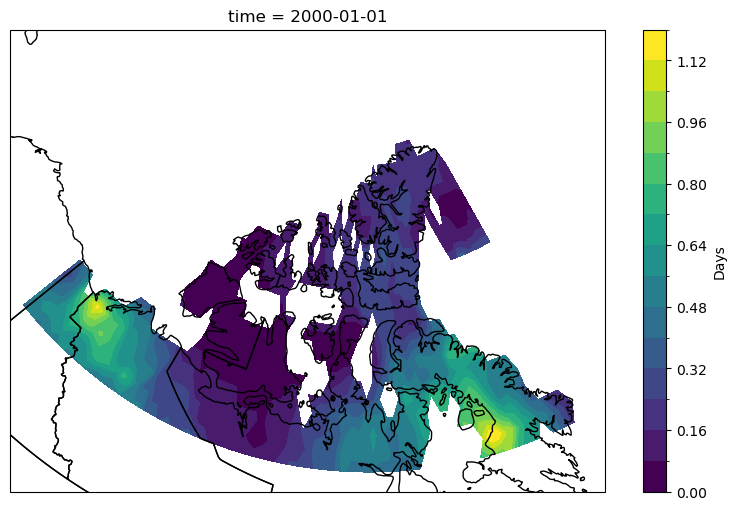

In [16]:
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# plot the data with 20 filled contours
test_result["mean"].plot.contourf(ax = ax, 
                                  transform = ccrs.PlateCarree(),
                                  levels = 20, 
                                  cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                 )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
# ax.set_title(f"Temperature on {sample_time}")

plt.show()

## GCM data
Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling.

In [2]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

['https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r10i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r1i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r2i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r3i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r4i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ou

This time we will use CanESM5 ensemble member r10i1p2f1

In [ ]:
# download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)
    
# if there is an error downloading a file, you'll need to either delete the file,
# or change this block of code to call download(url, path_to_write) without 
# first checking if path_to_write exists,

In [21]:
url_sds = datasets_canesm_sds[10] #SSP2-4.5; ensemble member: r10i1p2f1
print(url_sds)
downscaled_ds = xr.open_dataset(url_sds)

# tasmin and tasmax already in DegC, no need to convert units

# select spatial domain
lat_bnds = [65, 90]
lon_bnds = [-142, -60]

# select spatial domain
downscaled_ds = downscaled_ds.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

# select GCM data for historical and future periods
downscaled_hist = downscaled_ds.sel(time = downscaled_ds.time.dt.year.isin(range(2000, 2020)))
downscaled_future = downscaled_ds.sel(time = downscaled_ds.time.dt.year.isin(range(2080, 2101)))

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp245_r10i1p2f1_gn_1950-2100.ncml


In [31]:
downscaled_future_subset = downscaled_ds.sel(time = downscaled_ds.time.dt.year.isin(range(2100, 2101)))
downscaled_future_subset

<xarray.Dataset>
Dimensions:  (lon: 972, lat: 222, time: 365)
Coordinates:
  * lon      (lon) float64 -141.0 -140.9 -140.8 -140.7 ... -60.21 -60.13 -60.04
  * lat      (lat) float64 65.04 65.12 65.21 65.29 ... 83.21 83.29 83.37 83.46
  * time     (time) object 2100-01-01 00:00:00 ... 2100-12-31 00:00:00
Data variables:
    tasmin   (time, lat, lon) float32 ...
    tasmax   (time, lat, lon) float32 ...
    pr       (time, lat, lon) float32 ...
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2021-01-11T23:10:53PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

In [32]:
test_result = get_suitability(downscaled_future_subset)

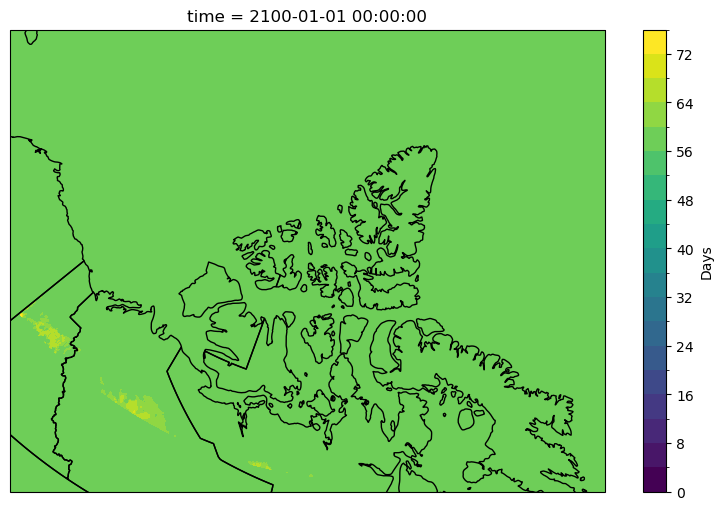

In [33]:
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# plot the data with 20 filled contours
test_result["mean"].plot.contourf(ax = ax, 
                                  transform = ccrs.PlateCarree(),
                                  levels = 20, 
                                  cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                 )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
# ax.set_title(f"Temperature on {sample_time}")

plt.show()

## Raw GCM

In [48]:
# Get the data for the raw simulation from ESGF for this same ensemble member.
# this time we'll use the OPeNDAP URL for the ESGF node, so we don't need to download and save the files.
conn = SearchConnection('http://esgf-data.dkrz.de/esg-search', distrib = True)

# The above does not work, try the following:
# LNLL node
#conn = SearchConnection('https://esgf-node.llnl.gov/esg-search', distrib=True)
# UK node
#conn = SearchConnection('https://esgf.ceda.ac.uk/esg-search', distrib= True)
# French node
#conn = SearchConnection('https://esgf-node.ipsl.upmc.fr/esg-search', distrib = True)

In [49]:
query = conn.new_context(latest = True, # search for most recent versions of the file
                         project="CMIP6",
                         experiment_id='historical, ssp245',
                         source_id = "CanESM5",
                         frequency = 'day', # daily
                         member_id="r9i1p2f1", # different ensemble member as before
                         variable_id = "tas")

results = query.search()

len(results)

4

In [50]:
# Make a pd.DataFrame mapping the file names to the URLs.
# sometimes running this cell raises an error, but running it a second time seems to work.
files = []
for i in range(len(results)):
    hit = results[i].file_context().search()
    files += list(map(lambda f: {'filename': f.filename, 
                                 'download_url': f.download_url, 
                                 'opendap_url': f.opendap_url}, hit))
files = pd.DataFrame.from_dict(files)
len(files)

4

In [51]:
# Print out all of the file names to check for duplicates, before we do any downloading

for fname in files['filename'].sort_values(): # print in alphabetical order
    print(fname)

tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_historical_r9i1p2f1_gn_18500101-20141231.nc
tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc
tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21001231.nc


In [52]:
# filter the DataFrame to drop duplicate filenames
files = files.drop_duplicates('filename')
files

,filename,download_url,opendap_url
0,tas_day_CanESM5_historical_r9i1p2f1_gn_1850010...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...
1,tas_day_CanESM5_ssp245_r9i1p2f1_gn_20150101-21...,https://esgf.ceda.ac.uk/thredds/fileServer/esg...,https://esgf.ceda.ac.uk/thredds/dodsC/esg_cmip...


In [43]:
# Adapted from: https://stackoverflow.com/a/37573701
def download(url, filename):
    """
    Download a file hosted at <url> and write to <filename>
    """
    print("Downloading ", filename)
    r = requests.get(url, stream=True)
    total_size, block_size = int(r.headers.get('content-length', 0)), 1024
    with open(filename, 'wb') as f:
        for data in tqdm(r.iter_content(block_size),
                         total=total_size//block_size,
                         unit='KiB', unit_scale=True):
            f.write(data)

    if total_size != 0 and os.path.getsize(filename) != total_size:
        print("Downloaded size does not match expected size!\n",
              "FYI, the status code was ", r.status_code)

In [7]:
# create a directory (inside the current working directory) to save the data to
data_directory = "data-raw/climate-data"
if not os.path.exists(data_directory): # only make the directory if it doesn't already exist
    os.mkdir(data_directory)

In [54]:
# download the data, one file at a time
for i in range(len(files)):
    url = files['download_url'].loc[i]
    filename = files['filename'].loc[i]
    path_to_write = os.path.join(data_directory, filename)
    
    # only download if the files doesn't already exist. 
    if not os.path.exists(path_to_write): 
        download(url, path_to_write)

813kKiB [1:01:22, 221KiB/s]                           


In [9]:
# first open the CanESM5 data, all files at once - open_mfdataset will automatically concatenate them in time
raw_CanESM5 = xr.open_mfdataset(data_directory + "/*_day_CanESM5*_r9i1p2f1*.nc")

# Convert unit
raw_CanESM5['tas'] = raw_CanESM5['tas'] - 273.15 #Convert to degree Celsius
# update the units in the file as well
raw_CanESM5['tas'].attrs['units'] = 'degC'

# select spatial domain
lat_bnds = [59, 90]
lon_bnds = [-143, -59]

# get lons bounds on [0, 360] scal
lons360 = [l + 360 for l in lon_bnds]
raw_hist = raw_CanESM5.sel(lat = slice(*lat_bnds), lon = slice(*lons360), 
                        time = raw_CanESM5.time.dt.year.isin(range(2020, 2021)))
raw_middle = raw_CanESM5.sel(lat = slice(*lat_bnds), lon = slice(*lons360), 
                        time = raw_CanESM5.time.dt.year.isin(range(2060, 2061)))

raw_future = raw_CanESM5.sel(lat = slice(*lat_bnds), lon = slice(*lons360), 
                        time = raw_CanESM5.time.dt.year.isin(range(2100, 2101)))

# convert back to [-180, 180] to match sds data
raw_hist = raw_hist.assign_coords(lon = raw_hist.lon - 360)
raw_middle = raw_middle.assign_coords(lon = raw_middle.lon - 360)
raw_future = raw_future.assign_coords(lon = raw_future.lon - 360)

In [26]:
raw_hist

<xarray.Dataset>
Dimensions:    (time: 365, bnds: 2, lat: 11, lon: 30)
Coordinates:
  * time       (time) object 2020-01-01 12:00:00 ... 2020-12-31 12:00:00
  * lat        (lat) float64 60.0 62.79 65.58 68.37 ... 79.53 82.31 85.1 87.86
  * lon        (lon) float64 -140.6 -137.8 -135.0 ... -64.69 -61.88 -59.06
    height     float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(365, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 dask.array<chunksize=(11, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 dask.array<chunksize=(30, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 dask.array<chunksize=(365, 11, 30), meta=np.ndarray>
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          p2-his09
    CCCma_pycmor_hash:           7c87dd3a822d55650b3c17cd65db0ca251282530
    CCCma_runid:                 p2-s4509
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/8f29dc0a-5882-4e53-bf04-09a5a91...
    variable_id:                 tas
    variant_label:               r9i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [10]:
hist_result = get_suitability(raw_hist, thres = 0.001)
middle_result = get_suitability(raw_middle, thres = 0.001)
future_result = get_suitability(raw_future, thres = 0.001)
hist_result

<xarray.Dataset>
Dimensions:  (lat: 11, lon: 30)
Coordinates:
  * lat      (lat) float64 60.0 62.79 65.58 68.37 ... 79.53 82.31 85.1 87.86
  * lon      (lon) float64 -140.6 -137.8 -135.0 -132.2 ... -64.69 -61.88 -59.06
    height   float64 2.0
    time     object 2020-01-01 12:00:00
Data variables:
    mean     (lat, lon) float64 dask.array<chunksize=(11, 30), meta=np.ndarray>
    std      (lat, lon) float64 dask.array<chunksize=(11, 30), meta=np.ndarray>
    neff     (lat, lon) float64 dask.array<chunksize=(11, 30), meta=np.ndarray>

In [28]:
raw_hist

<xarray.Dataset>
Dimensions:    (time: 365, bnds: 2, lat: 11, lon: 30)
Coordinates:
  * time       (time) object 2020-01-01 12:00:00 ... 2020-12-31 12:00:00
  * lat        (lat) float64 60.0 62.79 65.58 68.37 ... 79.53 82.31 85.1 87.86
  * lon        (lon) float64 -140.6 -137.8 -135.0 ... -64.69 -61.88 -59.06
    height     float64 ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object dask.array<chunksize=(365, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 dask.array<chunksize=(11, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 dask.array<chunksize=(30, 2), meta=np.ndarray>
    tas        (time, lat, lon) float32 dask.array<chunksize=(365, 11, 30), meta=np.ndarray>
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          p2-his09
    CCCma_pycmor_hash:           7c87dd3a822d55650b3c17cd65db0ca251282530
    CCCma_runid:                 p2-s4509
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   2015:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/8f29dc0a-5882-4e53-bf04-09a5a91...
    variable_id:                 tas
    variant_label:               r9i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

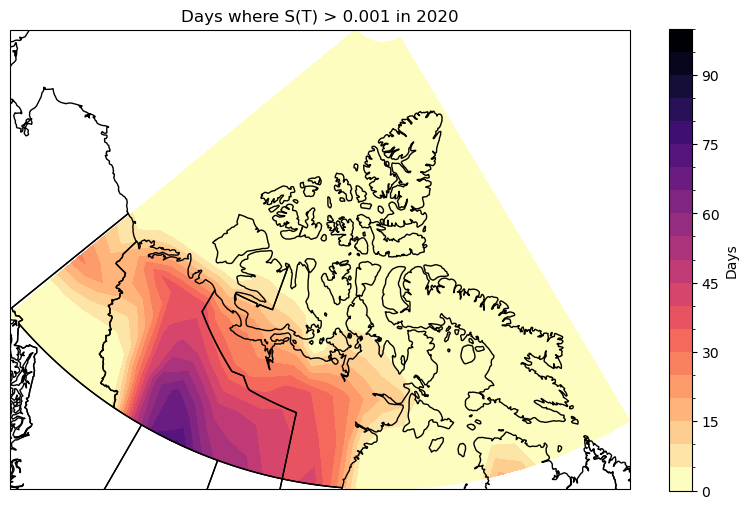

In [11]:
levels = np.arange(0, 105, 5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# plot the data with 20 filled contours
hist_result["mean"].plot.contourf(ax = ax, 
                                  transform = ccrs.PlateCarree(),
                                  levels = levels, 
                                  cmap = 'magma_r',
                                  cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                 )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
ax.set_title("Days where S(T) > 0.001 in 2020")

plt.savefig("figures/S_0.001_2020.png", dpi=300, bbox_inches="tight")
plt.show()

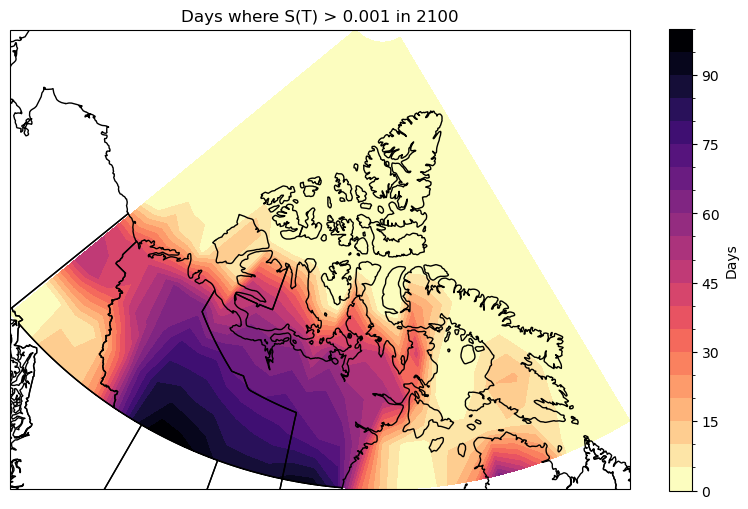

In [12]:
levels = np.arange(0, 105, 5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# plot the data with 20 filled contours
future_result["mean"].plot.contourf(ax = ax, 
                                    transform = ccrs.PlateCarree(),
                                    levels = levels, 
                                    cmap = 'magma_r',
                                    cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                   )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/S_0.001_2100.png", dpi=300, bbox_inches="tight")
plt.show()

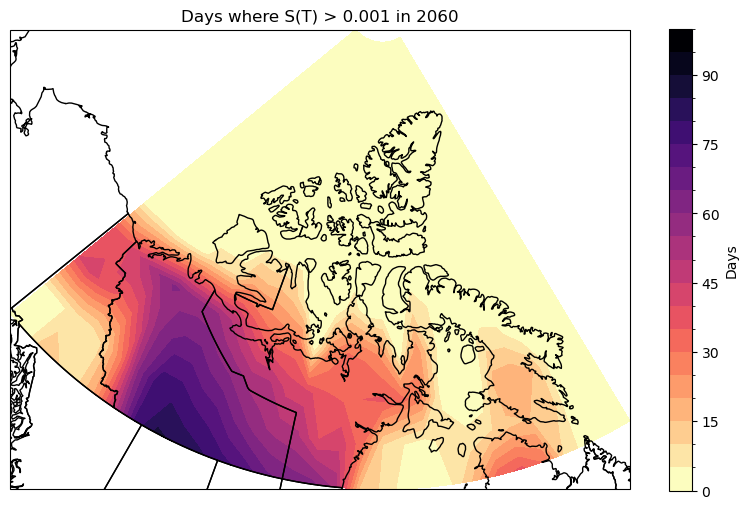

In [13]:
levels = np.arange(0, 105, 5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# plot the data with 20 filled contours
middle_result["mean"].plot.contourf(ax = ax, 
                                    transform = ccrs.PlateCarree(),
                                    levels = levels, 
                                    cmap = 'magma_r',
                                    cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                   )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
ax.set_title("Days where S(T) > 0.001 in 2060")

plt.savefig("figures/S_0.001_2060.png", dpi=300, bbox_inches="tight")
plt.show()

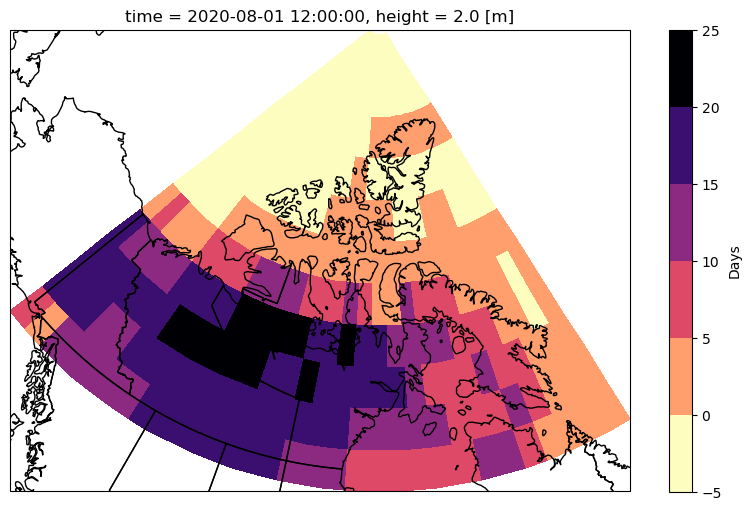

In [44]:
levels = np.arange(-5, 30, 5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# select the temperature data for a particular day
sample_time = '2020-08-01'
temp_sample = raw_hist.tas.sel(time = sample_time) 



# plot the data
temp_sample[0].plot.pcolormesh(ax = ax, 
                                    transform = ccrs.PlateCarree(),
                                    levels = levels, 
                                    cmap = 'magma_r',
                                    cbar_kwargs = {'label': 'Days', 
                                                 'orientation': 'vertical'}
                                   )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
#ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/temp.20200801.png", dpi=300, bbox_inches="tight")
plt.show()